# Replica Exchange MCMC for Overlapping Genes

**Parallel Tempering** runs multiple replicas at different temperatures and periodically swaps
configurations between adjacent temperature levels. Cold replicas explore low-energy regions while
hot replicas can cross energy barriers, feeding diverse conformations down to the coldest chain.

Each overlapping gene has **two independent proteins** with different DCA energy scales, so we use
**independent temperature ladders** (T1 for protein 1, T2 for protein 2). Both the Metropolis
criterion and the swap criterion use **z-score normalized** energies (`dE/std`) so that the two
proteins contribute equally regardless of their absolute energy scales.

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import json
import os
import sys

# Style
try:
    import seaborn as sns
    sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
    sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                                'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})
except ImportError:
    plt.style.use('ggplot')

from overlappingGenes import (
    extract_params, initial_seq_no_stops, load_natural_energies,
    overlapped_sequence_generator_int, seq_str_to_int_array,
    make_geometric_ladder, overlapped_sequence_generator_replica_exchange,
    run_replica_exchange, split_sequence_and_to_aa,
)

colorTable = {'k': [0,0,0], 'g': [27/255,158/255,119/255], 'o': [217/255,95/255,2/255]}

## Parameters

In [134]:
# Protein families
PROTEIN_1 = 'PF00004'
PROTEIN_2 = 'PF00041'
OVERLAP = 62          # nucleotides
READING_FRAME = '3-0' # default for initial_seq_no_stops

# Replica exchange parameters
N_REPLICAS = 10
N_ITERATIONS = 30_000
SWAP_INTERVAL = 1000   # MC steps between swap attempts (higher = more equilibration)
SAVE_INTERVAL = 1000

# Temperature bounds (None = use optimal from JSON * scaling)
T1_MIN = None  # will be loaded from optimal_temperatures.json
T1_MAX = None  # default: 4 * T1_MIN
T2_MIN = None
T2_MAX = None

In [135]:
# Data paths
root = '../Large Scale/bmDCA/'

# Load DCA parameters
dcaparams1 = os.path.join(root, PROTEIN_1, f'{PROTEIN_1}_params.dat')
dcaparams2 = os.path.join(root, PROTEIN_2, f'{PROTEIN_2}_params.dat')
Js_1, hs_1 = extract_params(dcaparams1)
Js_2, hs_2 = extract_params(dcaparams2)

DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]

# Protein lengths (AA, without stop)
lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PROTEIN_1}): {int(lenprot1)} AA = {int(3*lenprot1)} nt")
print(f"Protein 2 ({PROTEIN_2}): {int(lenprot2)} AA = {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP} nt")

# Load natural energies
nat_e1 = load_natural_energies(os.path.join(root, PROTEIN_1, f'{PROTEIN_1}_naturalenergies.txt'))
nat_e2 = load_natural_energies(os.path.join(root, PROTEIN_2, f'{PROTEIN_2}_naturalenergies.txt'))
nat_mean1, nat_std1 = np.mean(nat_e1), np.std(nat_e1)
nat_mean2, nat_std2 = np.mean(nat_e2), np.std(nat_e2)
print(f"Natural E1: {nat_mean1:.2f} +/- {nat_std1:.2f}")
print(f"Natural E2: {nat_mean2:.2f} +/- {nat_std2:.2f}")

# Load optimal temperatures (calibrated for raw energies)
with open('../Large Scale/optimal_temperatures.json', 'r') as f:
    optimal_temps = json.load(f)

# Rescale for z-score mode: T_z = T_raw / nat_std
# The Metropolis criterion uses (dE/std)/T, so temperatures must be in z-score units
if T1_MIN is None:
    T1_MIN = optimal_temps[PROTEIN_1] / nat_std1
if T2_MIN is None:
    T2_MIN = optimal_temps[PROTEIN_2] / nat_std2
if T1_MAX is None:
    T1_MAX = 4.0 * T1_MIN
if T2_MAX is None:
    T2_MAX = 4.0 * T2_MIN

print(f"\nRaw optimal temps: T1={optimal_temps[PROTEIN_1]:.4f}, T2={optimal_temps[PROTEIN_2]:.4f}")
print(f"Z-score rescaled:  T1={T1_MIN:.4f} (/{nat_std1:.2f}), T2={T2_MIN:.4f} (/{nat_std2:.2f})")

T1_ladder = make_geometric_ladder(T1_MIN, T1_MAX, N_REPLICAS)
T2_ladder = make_geometric_ladder(T2_MIN, T2_MAX, N_REPLICAS)
print(f"\nT1 ladder ({PROTEIN_1}): {np.array2string(T1_ladder, precision=4)}")
print(f"T2 ladder ({PROTEIN_2}): {np.array2string(T2_ladder, precision=4)}")

Protein 1 (PF00004): 110 AA = 330 nt
Protein 2 (PF00041): 74 AA = 222 nt
Overlap: 62 nt
Natural E1: 145.88 +/- 38.25
Natural E2: 120.66 +/- 17.64

Raw optimal temps: T1=0.8365, T2=0.9733
Z-score rescaled:  T1=0.0219 (/38.25), T2=0.0552 (/17.64)

T1 ladder (PF00004): [0.0219 0.0255 0.0298 0.0347 0.0405 0.0472 0.0551 0.0643 0.075  0.0875]
T2 ladder (PF00041): [0.0552 0.0644 0.0751 0.0876 0.1022 0.1192 0.1391 0.1622 0.1892 0.2207]


In [136]:
# JIT warmup: small run to trigger Numba compilation
print("JIT warmup (2 replicas, 500 iterations)...")
warmup_t0 = time.time()
_ = run_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP,
    n_replicas=2, n_iterations=500,
    swap_interval=100, save_interval=100,
    T1_ladder=T1_ladder[:2], T2_ladder=T2_ladder[:2],
    nat_mean1=nat_mean1, nat_mean2=nat_mean2,
    nat_std1=nat_std1, nat_std2=nat_std2,
)
print(f"Warmup done in {time.time() - warmup_t0:.1f}s (includes compilation)")

JIT warmup (2 replicas, 500 iterations)...
T1 ladder: [0.0219 0.0255]
T2 ladder: [0.0552 0.0644]
Replica exchange completed in 0.00 seconds.
Best energies: E1 = 338.1739, E2 = 240.8864
Swap acceptance rates: [1.]
Warmup done in 0.0s (includes compilation)


In [137]:
# Run full replica exchange
print(f"Running replica exchange: {N_REPLICAS} replicas, {N_ITERATIONS:,} iterations...")
results = run_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP,
    n_replicas=N_REPLICAS,
    n_iterations=N_ITERATIONS,
    swap_interval=SWAP_INTERVAL,
    save_interval=SAVE_INTERVAL,
    T1_ladder=T1_ladder, T2_ladder=T2_ladder,
    nat_mean1=nat_mean1, nat_mean2=nat_mean2,
    nat_std1=nat_std1, nat_std2=nat_std2,
)

Running replica exchange: 10 replicas, 30,000 iterations...
T1 ladder: [0.0219 0.0255 0.0298 0.0347 0.0405 0.0472 0.0551 0.0643 0.075  0.0875]
T2 ladder: [0.0552 0.0644 0.0751 0.0876 0.1022 0.1192 0.1391 0.1622 0.1892 0.2207]
Replica exchange completed in 0.25 seconds.
Best energies: E1 = 205.1105, E2 = 119.0592
Swap acceptance rates: [0.133 0.267 0.267 0.333 0.267 0.533 0.267 0.267 0.133]


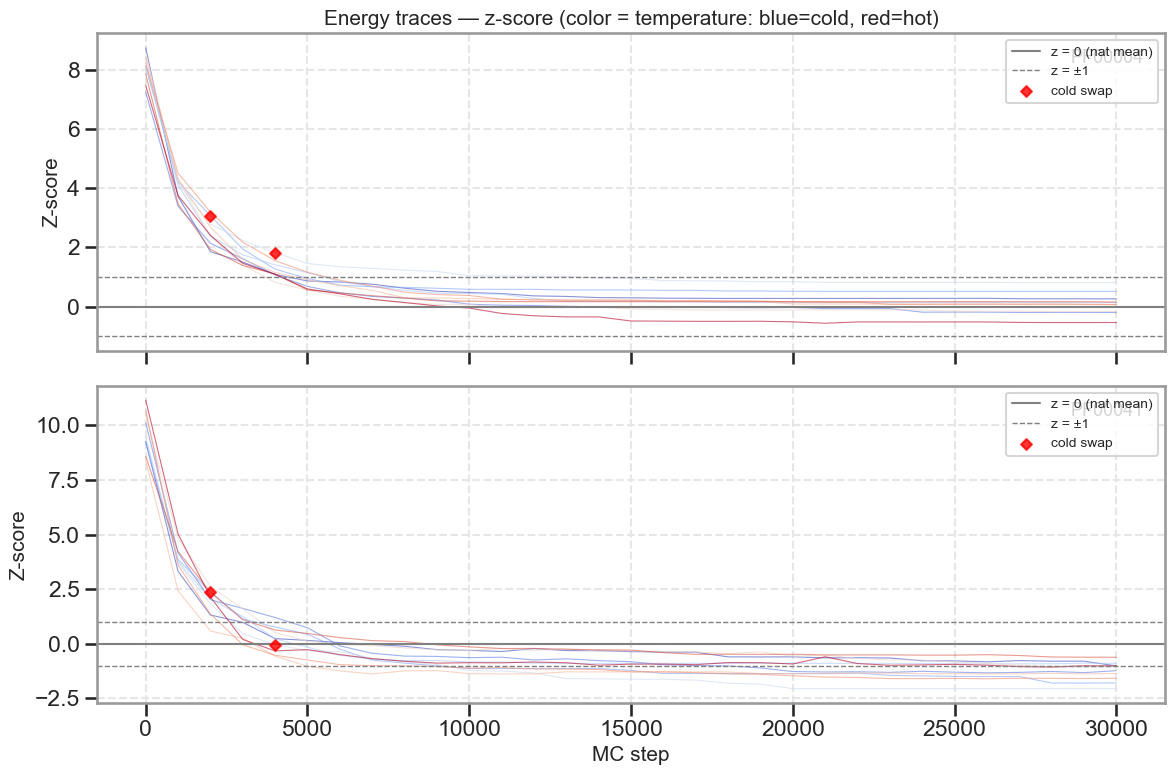

In [138]:
# ── Plot 1: Energy traces (z-scores) + swap markers ──

eh1 = results['energy_history_1']  # (n_replicas, n_saves)
eh2 = results['energy_history_2']
n_saves = eh1.shape[1]
x_saves = np.arange(n_saves) * SAVE_INTERVAL

# Convert to z-scores
zh1 = (eh1 - nat_mean1) / nat_std1
zh2 = (eh2 - nat_mean2) / nat_std2

# Color map: cold (blue) → hot (red)
cmap = plt.cm.coolwarm
colors = [cmap(i / (N_REPLICAS - 1)) for i in range(N_REPLICAS)]

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for c in range(N_REPLICAS):
    axs[0].plot(x_saves, zh1[c], color=colors[c], alpha=0.6, lw=0.8)
    axs[1].plot(x_saves, zh2[c], color=colors[c], alpha=0.6, lw=0.8)

# Z-score reference lines: z=0 (mean), z=±1
for ax, label in [(axs[0], PROTEIN_1), (axs[1], PROTEIN_2)]:
    ax.axhline(0, color='gray', ls='-', lw=1.5, label='z = 0 (nat mean)')
    ax.axhline(1, color='gray', ls='--', lw=1, label='z = ±1')
    ax.axhline(-1, color='gray', ls='--', lw=1)
    ax.set_ylabel('Z-score')
    ax.text(0.98, 0.95, label, ha='right', va='top', transform=ax.transAxes,
            fontsize=13, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# Mark accepted swap events involving coldest replica as scatter points
swap_hist = results['swap_history']
cold_swaps = swap_hist[(swap_hist[:, 3] == 1.0) & ((swap_hist[:, 1] == 0) | (swap_hist[:, 2] == 0))]

if len(cold_swaps) > 0:
    # Reconstruct coldest-replica z-score at each swap step
    rih = results['replica_index_history']
    for ax, zh, label_name in [(axs[0], zh1, PROTEIN_1), (axs[1], zh2, PROTEIN_2)]:
        swap_x = []
        swap_y = []
        for s in cold_swaps:
            step = int(s[0])
            save_idx = step // SAVE_INTERVAL
            if save_idx < n_saves:
                # Find which config is at temp 0 at this save point
                for c in range(N_REPLICAS):
                    if rih[c, save_idx] == 0:
                        swap_x.append(step)
                        swap_y.append(zh[c, save_idx])
                        break
        ax.scatter(swap_x, swap_y, marker='D', s=30, color='red',
                   zorder=5, alpha=0.8, label='cold swap')
        ax.legend(fontsize=10, loc='upper right')

axs[-1].set_xlabel('MC step')
axs[0].set_title('Energy traces — z-score (color = temperature: blue=cold, red=hot)')
plt.tight_layout()
plt.show()

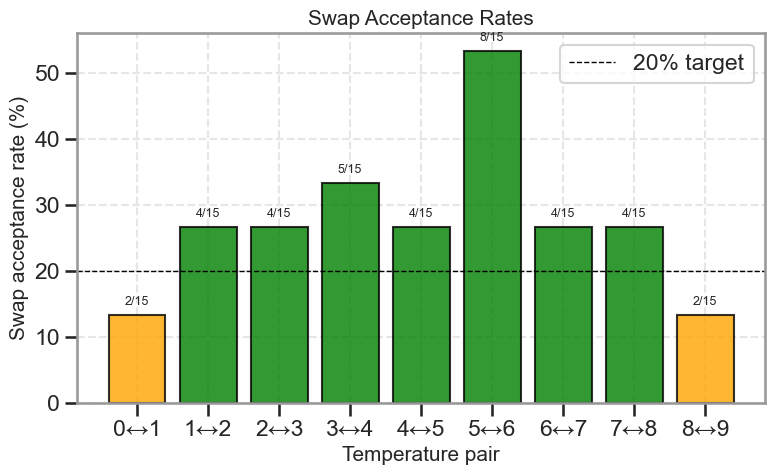

In [139]:
# ── Plot 2: Swap acceptance rates ──

swap_rates = results['swap_rates']
n_pairs = len(swap_rates)
pair_labels = [f'{i}↔{i+1}' for i in range(n_pairs)]

bar_colors = []
for r in swap_rates:
    if r >= 0.20:
        bar_colors.append('green')
    elif r >= 0.10:
        bar_colors.append('orange')
    else:
        bar_colors.append('red')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(n_pairs), swap_rates * 100, color=bar_colors, edgecolor='k', alpha=0.8)
ax.axhline(20, color='k', ls='--', lw=1, label='20% target')
ax.set_xticks(range(n_pairs))
ax.set_xticklabels(pair_labels)
ax.set_xlabel('Temperature pair')
ax.set_ylabel('Swap acceptance rate (%)')
ax.set_title('Swap Acceptance Rates')
ax.legend()

# Annotate counts
for i, bar in enumerate(bars):
    count = int(results['swap_acceptance_counts'][i])
    total = int(results['swap_attempt_counts'][i])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{count}/{total}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

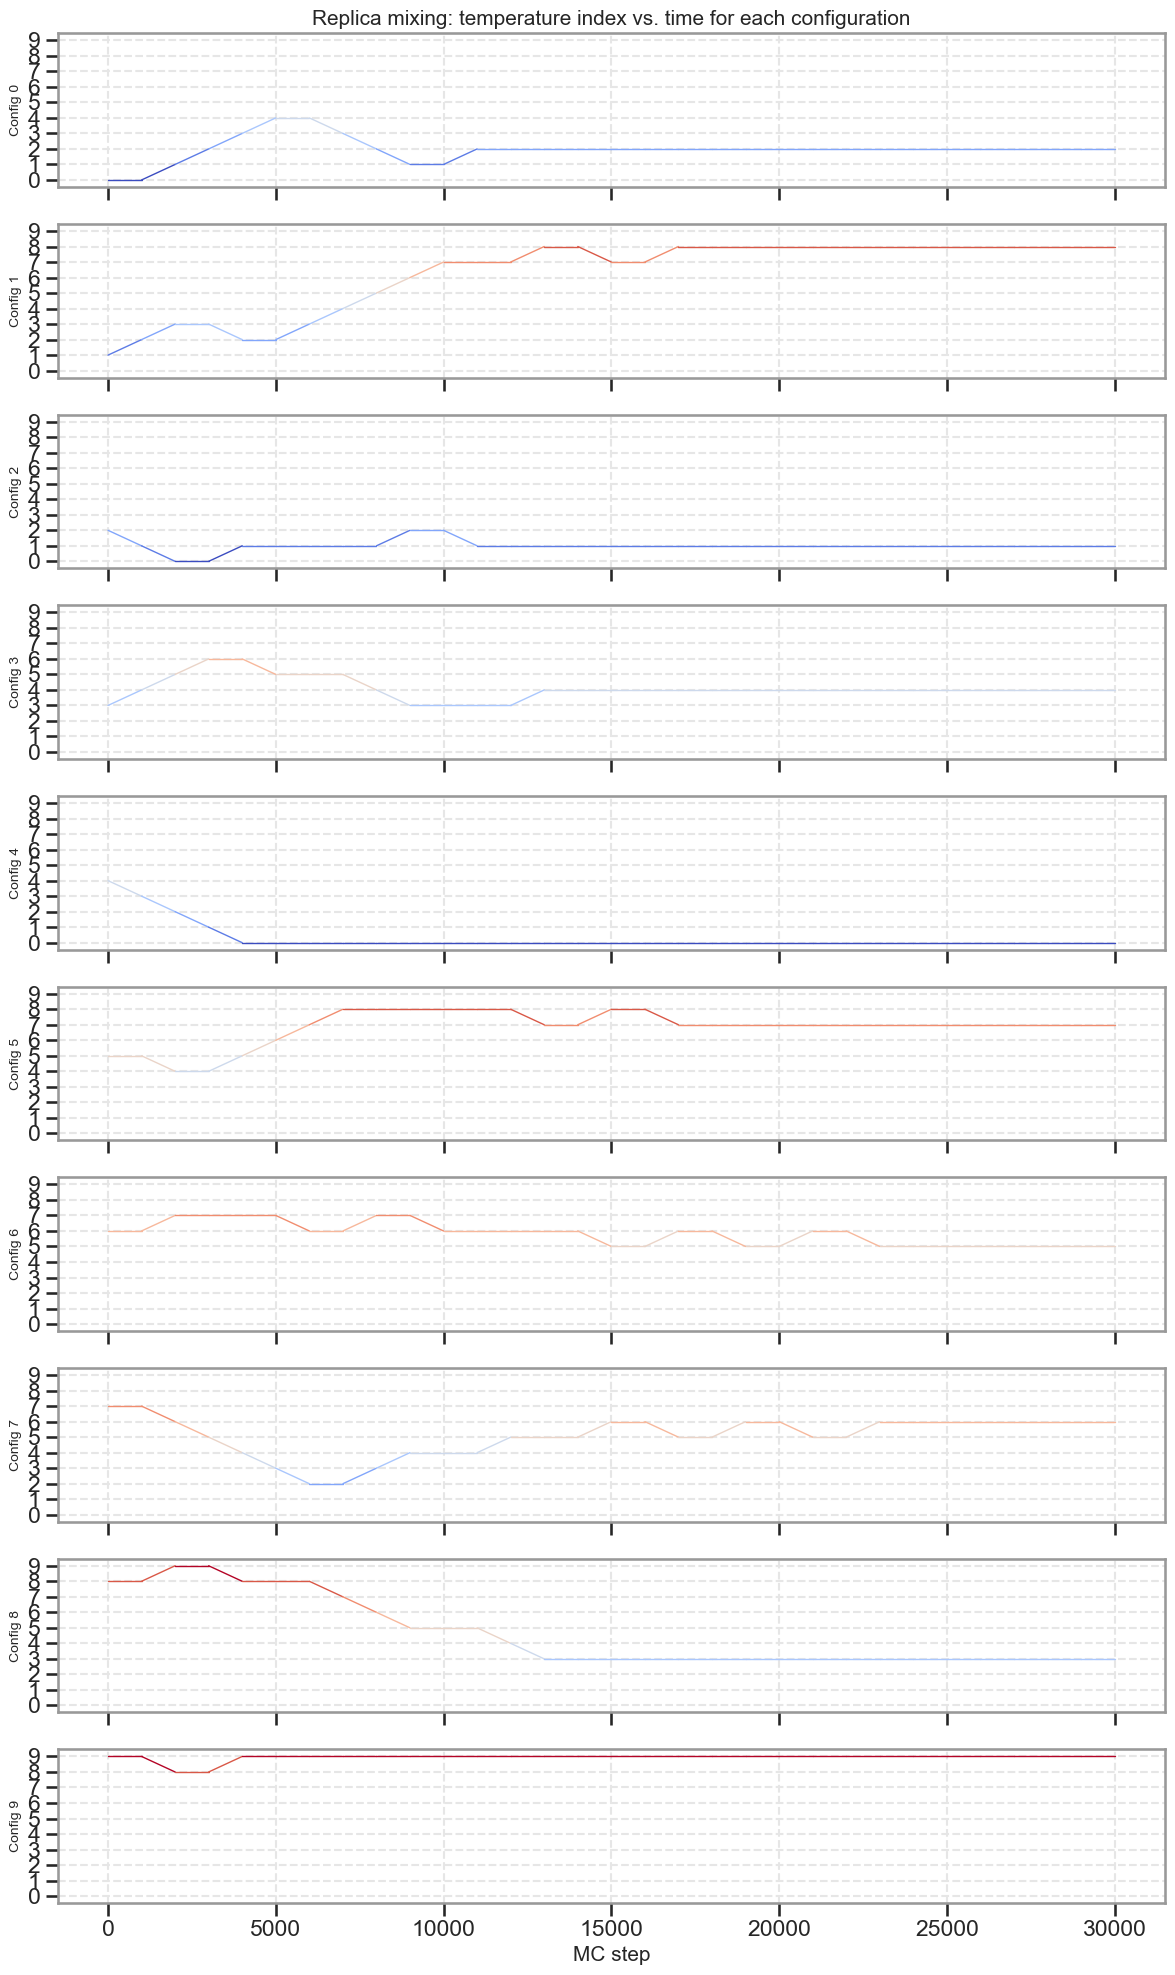

In [140]:
# ── Plot 3: Replica mixing ──
# Each subplot row shows the temperature index over time for one configuration

rih = results['replica_index_history']  # (n_replicas, n_saves)
n_saves = rih.shape[1]
x_saves = np.arange(n_saves) * SAVE_INTERVAL

fig, axs = plt.subplots(N_REPLICAS, 1, figsize=(12, 2 * N_REPLICAS), sharex=True, sharey=True)
if N_REPLICAS == 1:
    axs = [axs]

cmap = plt.cm.coolwarm
for c in range(N_REPLICAS):
    temp_indices = rih[c]
    # Color each segment by current temperature
    for s in range(n_saves - 1):
        t_idx = int(temp_indices[s])
        axs[c].plot(x_saves[s:s+2], temp_indices[s:s+2],
                    color=cmap(t_idx / max(N_REPLICAS - 1, 1)), lw=1)
    axs[c].set_ylabel(f'Config {c}', fontsize=10)
    axs[c].set_yticks(range(N_REPLICAS))

axs[-1].set_xlabel('MC step')
axs[0].set_title('Replica mixing: temperature index vs. time for each configuration')
plt.tight_layout()
plt.show()

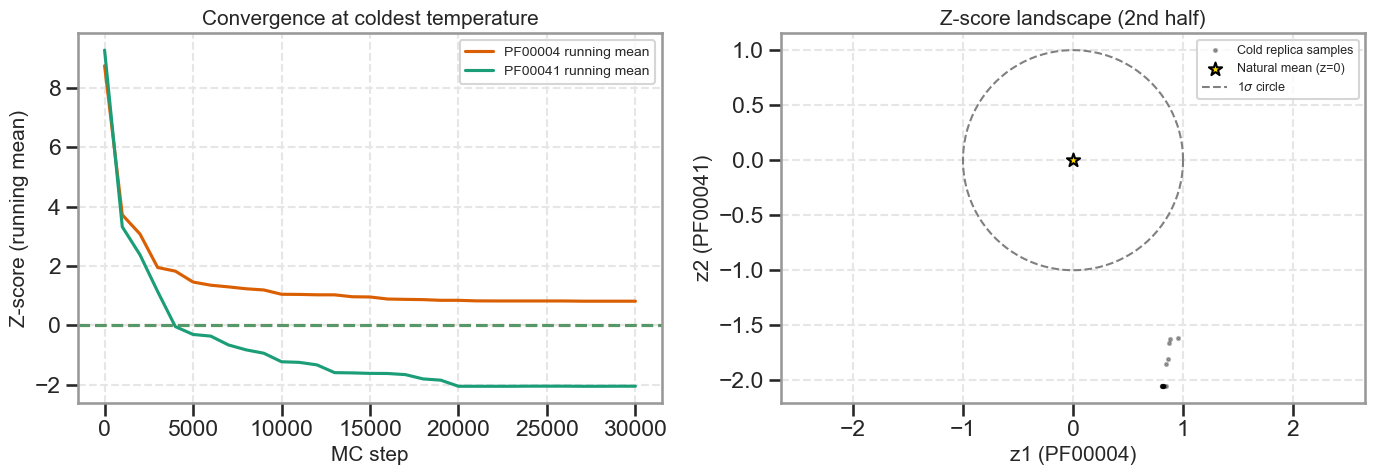

In [141]:
# ── Plot 4: Convergence diagnostics (z-scores) ──

rih_full = results['replica_index_history']  # (n_replicas, n_saves)
eh1_full = results['energy_history_1']
eh2_full = results['energy_history_2']
n_saves = eh1_full.shape[1]
x_saves = np.arange(n_saves) * SAVE_INTERVAL

# Reconstruct coldest-temperature energy trace
cold_E1 = np.empty(n_saves)
cold_E2 = np.empty(n_saves)
for s in range(n_saves):
    for c in range(N_REPLICAS):
        if rih_full[c, s] == 0:
            cold_E1[s] = eh1_full[c, s]
            cold_E2[s] = eh2_full[c, s]
            break

# Convert to z-scores
cold_z1 = (cold_E1 - nat_mean1) / nat_std1
cold_z2 = (cold_E2 - nat_mean2) / nat_std2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Running mean of z-scores
window = max(1, n_saves // 50)
running_z1 = np.convolve(cold_z1, np.ones(window)/window, mode='valid')
running_z2 = np.convolve(cold_z2, np.ones(window)/window, mode='valid')
x_running = x_saves[window-1:]

ax1.plot(x_running, running_z1, color=colorTable['o'], label=f'{PROTEIN_1} running mean')
ax1.axhline(0, color=colorTable['o'], ls='--', alpha=0.7)
ax1.plot(x_running, running_z2, color=colorTable['g'], label=f'{PROTEIN_2} running mean')
ax1.axhline(0, color=colorTable['g'], ls='--', alpha=0.7)
ax1.set_xlabel('MC step')
ax1.set_ylabel('Z-score (running mean)')
ax1.set_title('Convergence at coldest temperature')
ax1.legend(fontsize=10)

# Right: Scatter in (z1, z2) space with unit circle as 1-sigma
half = n_saves // 2
ax2.scatter(cold_z1[half:], cold_z2[half:], s=5, alpha=0.3, color='k', label='Cold replica samples')
ax2.scatter([0], [0], s=100, marker='*', color='gold', edgecolors='k',
            zorder=5, label='Natural mean (z=0)')

# Unit circle as 1-sigma boundary
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'gray', ls='--', lw=1.5, label=r'1$\sigma$ circle')

ax2.set_xlabel(f'z1 ({PROTEIN_1})')
ax2.set_ylabel(f'z2 ({PROTEIN_2})')
ax2.set_title('Z-score landscape (2nd half)')
ax2.set_aspect('equal', adjustable='datalim')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 5: Comparison with single-chain MCMC (z-scores) ──

# Single-chain uses raw dE/T Metropolis (no z-score normalization),
# so it needs raw optimal temperatures, not z-score-rescaled ones.
sc_T1 = optimal_temps[PROTEIN_1]
sc_T2 = optimal_temps[PROTEIN_2]
print(f"Running single-chain MCMC at T1={sc_T1:.4f}, T2={sc_T2:.4f} for {N_ITERATIONS:,} iterations...")
print(f"  (raw temps — single-chain Metropolis uses dE/T, not (dE/std)/T)")
sc_init = initial_seq_no_stops(lenprot1, lenprot2, OVERLAP, quiet=True)

# whentosave = fraction so that 1/whentosave = desired number of saves
# This gives the same number of save points as the RE trace
sc_whentosave = SAVE_INTERVAL / N_ITERATIONS
print(f"  whentosave={sc_whentosave:.4f} → ~{int(1/sc_whentosave)} save points")

sc_start = time.time()
sc_output = overlapped_sequence_generator_int(
    DCA_params_1, DCA_params_2, sc_init,
    T1=sc_T1, T2=sc_T2,
    numberofiterations=N_ITERATIONS,
    quiet=True, whentosave=sc_whentosave,
    nat_mean1=nat_mean1, nat_mean2=nat_mean2,
    nat_std1=nat_std1, nat_std2=nat_std2,
    use_z_score=True,
)
sc_elapsed = time.time() - sc_start
print(f"Single-chain done in {sc_elapsed:.2f}s")

sc_seq, sc_acc, sc_e1, sc_e2, sc_final_e, sc_best_e, sc_best_seq = sc_output
print(f"  {len(sc_e1)} energy samples saved")

# Convert to z-scores
sc_z1 = (np.array(sc_e1) - nat_mean1) / nat_std1
sc_z2 = (np.array(sc_e2) - nat_mean2) / nat_std2

# Plot comparison in z-score space
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Single-chain trace (z-scores)
sc_x = np.linspace(0, N_ITERATIONS, len(sc_z1))
axs[0].plot(sc_x, sc_z1, 'k', alpha=0.7, lw=0.8, label='Single-chain')
axs[1].plot(sc_x, sc_z2, 'k', alpha=0.7, lw=0.8, label='Single-chain')

# RE coldest replica (z-scores)
axs[0].plot(x_saves, cold_z1, color='tab:blue', alpha=0.7, lw=0.8, label='RE (coldest)')
axs[1].plot(x_saves, cold_z2, color='tab:blue', alpha=0.7, lw=0.8, label='RE (coldest)')

for ax, label in [(axs[0], PROTEIN_1), (axs[1], PROTEIN_2)]:
    ax.axhline(0, color='gray', ls='-', lw=1.5, label='z = 0 (nat mean)')
    ax.axhline(1, color='gray', ls='--', lw=1)
    ax.axhline(-1, color='gray', ls='--', lw=1)
    ax.set_ylabel('Z-score')
    ax.legend(fontsize=10, loc='upper right')
    ax.text(0.02, 0.95, label, ha='left', va='top', transform=ax.transAxes,
            fontsize=13, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

axs[-1].set_xlabel('MC step')
axs[0].set_title('Replica Exchange vs Single-Chain MCMC (z-scores)')
plt.tight_layout()
plt.show()

In [143]:
# ── Results summary ──

# Translate best sequence to amino acids
best_seq_str = results['best_sequence']
best_seq_list = list(best_seq_str)
len_1_n = int(3 * lenprot1 + 3)
len_2_n = int(3 * lenprot2 + 3)
aa1, aa2 = split_sequence_and_to_aa(best_seq_list, len_1_n, len_2_n)

print("=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)
print(f"\nBest RE sequence (nucleotides, length {len(best_seq_str)}):")
print(best_seq_str[:80] + '...' if len(best_seq_str) > 80 else best_seq_str)
print(f"\nProtein 1 ({PROTEIN_1}): {''.join(aa1)}")
print(f"Protein 2 ({PROTEIN_2}): {''.join(aa2)}")

# Compute z-scores for all energies
re_best_z1 = (results['best_energies'][0] - nat_mean1) / nat_std1
re_best_z2 = (results['best_energies'][1] - nat_mean2) / nat_std2
sc_best_z1 = (sc_best_e[0] - nat_mean1) / nat_std1
sc_best_z2 = (sc_best_e[1] - nat_mean2) / nat_std2
re_final_z1 = (results['energy_history_1'][0, -1] - nat_mean1) / nat_std1
re_final_z2 = (results['energy_history_2'][0, -1] - nat_mean2) / nat_std2
sc_final_z1 = (sc_final_e[0] - nat_mean1) / nat_std1
sc_final_z2 = (sc_final_e[1] - nat_mean2) / nat_std2

print(f"\n{'Metric':<30} {'RE':>12} {'(z)':>8} {'Single-chain':>14} {'(z)':>8} {'Natural':>12}")
print('-' * 86)
print(f"{'Best E1':<30} {results['best_energies'][0]:>12.2f} {re_best_z1:>8.2f} {sc_best_e[0]:>14.2f} {sc_best_z1:>8.2f} {nat_mean1:>12.2f}")
print(f"{'Best E2':<30} {results['best_energies'][1]:>12.2f} {re_best_z2:>8.2f} {sc_best_e[1]:>14.2f} {sc_best_z2:>8.2f} {nat_mean2:>12.2f}")
re_zdist = abs(re_best_z1) + abs(re_best_z2)
sc_zdist = abs(sc_best_z1) + abs(sc_best_z2)
print(f"{'Best z-dist':<30} {'':>12} {re_zdist:>8.3f} {'':>14} {sc_zdist:>8.3f} {'':>12}")
print(f"{'Final E1':<30} {results['energy_history_1'][0, -1]:>12.2f} {re_final_z1:>8.2f} {sc_final_e[0]:>14.2f} {sc_final_z1:>8.2f} {nat_mean1:>12.2f}")
print(f"{'Final E2':<30} {results['energy_history_2'][0, -1]:>12.2f} {re_final_z2:>8.2f} {sc_final_e[1]:>14.2f} {sc_final_z2:>8.2f} {nat_mean2:>12.2f}")
print(f"{'Runtime (s)':<30} {results['elapsed_time']:>12.1f} {'':>8} {sc_elapsed:>14.1f}")

print(f"\nTemperature rescaling: T_z = T_raw / nat_std")
print(f"  T1: {optimal_temps[PROTEIN_1]:.4f} / {nat_std1:.2f} = {T1_MIN:.4f}")
print(f"  T2: {optimal_temps[PROTEIN_2]:.4f} / {nat_std2:.2f} = {T2_MIN:.4f}")

print(f"\nSwap acceptance rates:")
for i, rate in enumerate(results['swap_rates']):
    attempts = int(results['swap_attempt_counts'][i])
    accepts = int(results['swap_acceptance_counts'][i])
    print(f"  Pair {i}↔{i+1}: {rate*100:.1f}% ({accepts}/{attempts})")

print(f"\nPer-replica acceptance (config order):")
for c in range(N_REPLICAS):
    acc = results['acceptance_counts'][c]
    total = acc.sum()
    if total > 0:
        print(f"  Config {c}: {(acc[0]+acc[1])/total*100:.1f}% accepted "
              f"({acc[0]:.0f} downhill, {acc[1]:.0f} uphill, {acc[2]:.0f} rejected)")

RESULTS SUMMARY

Best RE sequence (nucleotides, length 496):
GCCCTTGTATCCCCAAGGAACAGTTCTAAGAGTTCACTTGTTCGCGCTGTGAGCGCAGCGCTAAATGCACATGTTTTTGA...

Protein 1 (PF00004): ALVSPRNSSKSSLVRAVSAALNAHVFDLSLGGLASYVGASEGRLKQALRAAKAASPSVLLVRNIEKLFPAKSGSLADLLYPALQPGTSLVVTLATEPFLLPSELLSAFSL*
Protein 2 (PF00041): TNLRAVDVTDGTATVTFDAPSAPIDRVEVTASPAGGSGTEVSAGSSPITLTGLTVTTKMQIRVRSVKGRAQWLV*

Metric                                   RE      (z)   Single-chain      (z)      Natural
--------------------------------------------------------------------------------------
Best E1                              205.11     1.55         168.31     0.59       145.88
Best E2                              119.06    -0.09         120.54    -0.01       120.66
Best z-dist                                    1.639                   0.593             
Final E1                             155.98     0.26         168.31     0.59       145.88
Final E2                             102.79    -1.01         120.54    -0.01       120